# ReviewLens — Sentiment Analysis and Insight Dashboard
### Real Kaggle Review Data → Positive / Negative / Neutral Classification

| | |
|---|---|
| **Domain** | NLP · Sentiment Analysis |
| **Dataset** | 30,801 real reviews merged from 13 Kaggle datasets (Amazon, Flipkart, App Store, Play Store, Coursera, Zomato, IMDB, and others) |
| **Model** | TF-IDF + Logistic Regression (cross-validated hyperparameter search), Naive Bayes baseline |
| **Deployment** | Streamlit multi-page dashboard (`app.py`) |

This notebook walks through the exact same pipeline used by `train.py` and the
production dashboard — it imports directly from the `src/` package rather than
re-implementing anything, so results here are guaranteed to match the shipped
`models/pipeline.pkl`. That also means this notebook can be re-run end-to-end
to reproduce every number in `docs/PROJECT_REPORT.md`.


## 1. Problem Statement

Businesses receive thousands of customer reviews daily across multiple
platforms and cannot read them all manually. This project builds a model
that automatically classifies each review as **positive**, **negative**, or
**neutral**, and explains *why* — which words drove that classification —
so the results are usable, not a black box.

**Why real data, not synthetic:** training on real Kaggle reviews means the
class imbalance, ambiguity, and noise seen here are genuine properties of
real review text, not artifacts of a data generator. That makes the reported
accuracy numbers trustworthy rather than inflated.


## 2. Import Libraries

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# This notebook reuses the project's own source code — the same functions
# that power train.py and the Streamlit dashboard — rather than
# re-implementing the pipeline. That guarantees this notebook and the
# production app can never silently drift apart.
sys.path.insert(0, '.')
from src.preprocess import preprocess_text, preprocess_batch
from src.train_model import (
    build_lr_pipeline, build_nb_pipeline, evaluate_pipeline,
    tune_class_weights, get_top_features,
)
from src.explain import explain_prediction
from src.utils import load_dataset, LABEL_COLORS

from sklearn.model_selection import train_test_split

print('✅ Imports successful — using the same src/ modules as train.py and app.py')


✅ Imports successful — using the same src/ modules as train.py and app.py


## 3. Load the Real Dataset

`data/raw/reviews.csv` is the already-merged, cleaned output of
`prepare_dataset.py`, which combines 13 raw Kaggle CSVs (see
`src/data_sources.py` for the exact source list and column mappings) into one
unified schema: `review_text, rating, date, source, category, label`.

The raw Kaggle source files themselves (~250MB) aren't shipped in this
repo for size reasons — only the processed, ready-to-train result is.


In [2]:
df = load_dataset()
print(f'Dataset shape: {df.shape}')
df.head()


Loading dataset from /home/claude/reviewlens/data/raw/reviews.csv


Dataset shape: (30801, 6)


,review_text,rating,date,source,category,label
0,The first film ever made. Workers streaming fr...,NaN,NaN,IMDB,Movie,positive
1,Just great. Leads to emotionnal intelligence t...,5.0,NaN,Coursera,Course,positive
2,Nicht kompatibel 😩,3.0,2015-09-18 07:15:59,App Store,App,neutral
3,muy bueno y la explicación tambien,5.0,NaN,Coursera,Course,positive
4,Good for studying and doing revision,4.0,2020-10-22 20:30:56,Play Store,App,positive


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30801 entries, 0 to 30800
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   review_text  30801 non-null  str    
 1   rating       25457 non-null  float64
 2   date         13127 non-null  str    
 3   source       30801 non-null  str    
 4   category     30801 non-null  str    
 5   label        30801 non-null  str    
dtypes: float64(1), str(5)
memory usage: 11.5 MB


## 4. Exploratory Data Analysis

### 4.1 Label Distribution

This is the first thing worth checking — real review data is naturally imbalanced (satisfied customers write reviews far more often than lukewarm ones).

label
positive    21335
neutral      2150
negative     7316
Name: count, dtype: int64

Neutral share: 7.0%


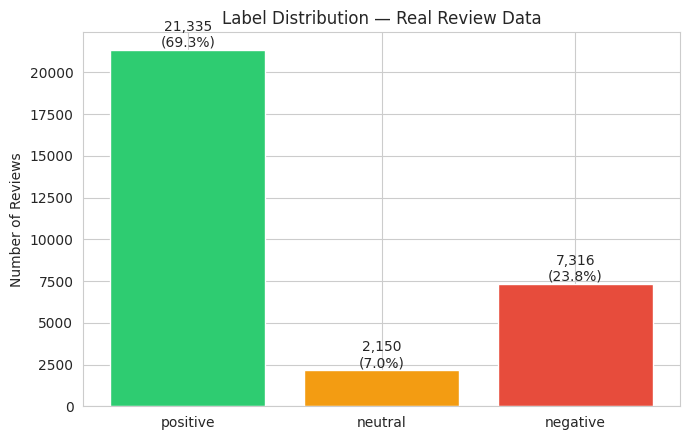

In [4]:
label_counts = df['label'].value_counts().reindex(['positive', 'neutral', 'negative'])
print(label_counts)
print(f'\nNeutral share: {label_counts["neutral"] / len(df):.1%}')

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [LABEL_COLORS[l] for l in label_counts.index]
bars = ax.bar(label_counts.index, label_counts.values, color=colors)
ax.set_title('Label Distribution — Real Review Data')
ax.set_ylabel('Number of Reviews')
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({count/len(df):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


**Finding:** positive reviews dominate (~69%), negative make up about a quarter, and neutral is a small minority (~7%). This imbalance — not a synthetic artifact, but a genuine property of real review data — is the single biggest factor behind every modelling decision in Section 7.

### 4.2 Category & Source Breakdown

The merged dataset spans 6 product categories and 8 platforms.

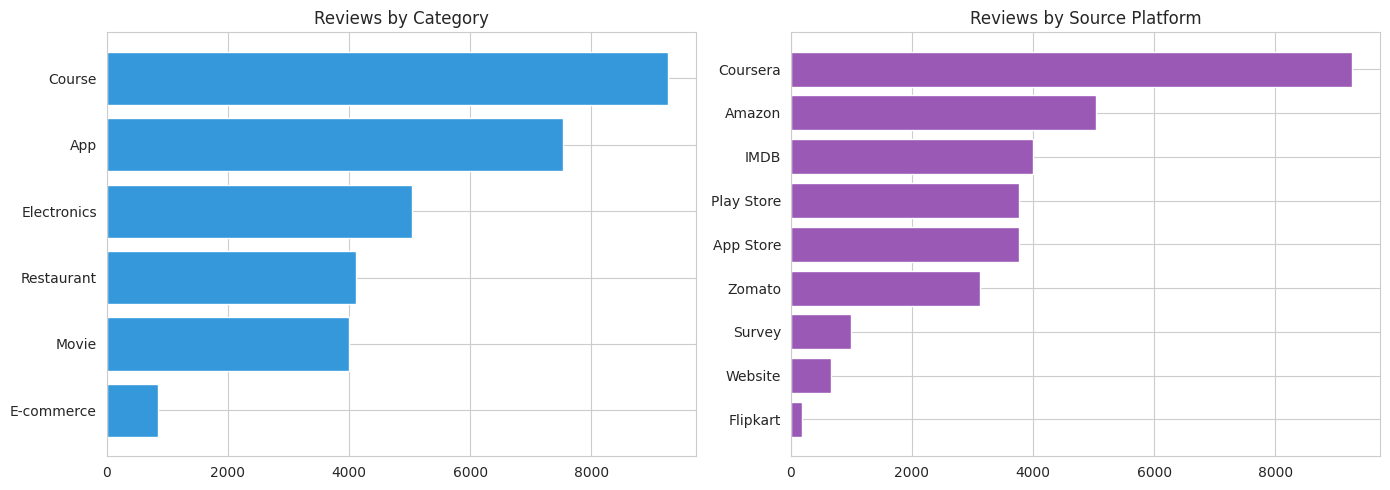

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df['category'].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color='#3498db')
axes[0].set_title('Reviews by Category')
axes[0].invert_yaxis()

src_counts = df['source'].value_counts()
axes[1].barh(src_counts.index, src_counts.values, color='#9b59b6')
axes[1].set_title('Reviews by Source Platform')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


### 4.3 Review Length Distribution

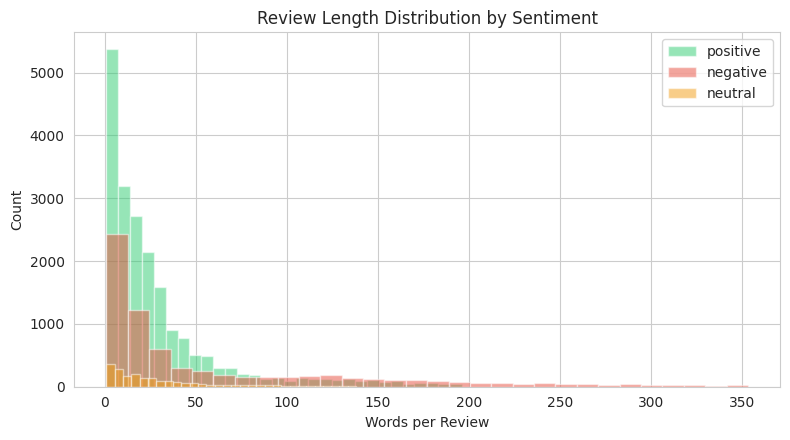

               mean   50%     max
label                            
negative  83.046473  25.0  1554.0
neutral   46.223256  21.0  3599.0
positive  46.872229  19.0  3601.0


In [6]:
df['word_count'] = df['review_text'].astype(str).str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4.5))
for label in ['positive', 'negative', 'neutral']:
    subset = df[df['label'] == label]['word_count']
    subset = subset[subset < subset.quantile(0.95)]  # trim outliers for a readable plot
    ax.hist(subset, bins=30, alpha=0.5, label=label, color=LABEL_COLORS[label])
ax.set_xlabel('Words per Review')
ax.set_ylabel('Count')
ax.set_title('Review Length Distribution by Sentiment')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('label')['word_count'].describe()[['mean', '50%', 'max']])


### 4.4 Word Clouds

A quick qualitative check before any modelling — do the raw words already look sentiment-appropriate?

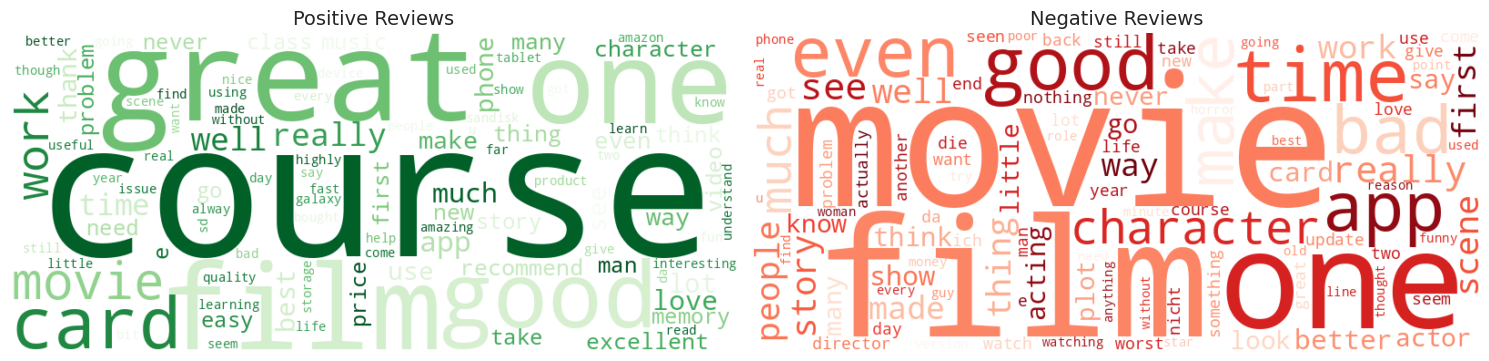

In [7]:
def make_wordcloud(texts, colormap):
    cleaned = ' '.join(preprocess_batch(texts.tolist()))
    return WordCloud(width=800, height=350, background_color='white',
                     colormap=colormap, max_words=100, collocations=False).generate(cleaned)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

wc_pos = make_wordcloud(df[df['label'] == 'positive']['review_text'].sample(3000, random_state=42), 'Greens')
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews', fontsize=14)
axes[0].axis('off')

wc_neg = make_wordcloud(df[df['label'] == 'negative']['review_text'].sample(3000, random_state=42), 'Reds')
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 5. Text Preprocessing Pipeline

`src/preprocess.py` applies, in order:
1. Lowercase conversion
2. HTML tag removal
3. URL removal
4. Special character removal (keep letters, digits, spaces)
5. Extra whitespace collapse
6. English stop-word removal (NLTK)
7. WordNet lemmatisation — cached per word, since review vocabulary is highly
   repetitive (see `src/preprocess.py :: _lemmatize_word`)


In [8]:
sample_review = df['review_text'].iloc[0]
cleaned = preprocess_text(sample_review)

print('BEFORE:')
print(f'  {sample_review!r}')
print()
print('AFTER:')
print(f'  {cleaned!r}')


BEFORE:
  "The first film ever made. Workers streaming from a factory, some cycling, most walking, moving right or left. Along with Melies, the Lumieres are both the starting point and the point of departure for cinema - with Melies begins narrative fiction, cinema, fantasy, artifice, spectacle; with the Lumieres pure, unadorned, observation. The truth. There are many intellectuals who regret the ossification of cinema from the latter into the tired formulae of the former.<br /><br />But consider this short again. There is nothing 'objective' about it. The film is full of action - a static, inhuman scene burst into life, activity, and the quiet harmony of the frame is ruptured, decentred from the back to right or left (but never, of course, the front, where the camera is). And yet the camera stands stock still, contains the energy, the possible subversion, subordinates it to its will. The cinematograph may be a revolutionary invention, but it will be used for conservative purposes - to

In [9]:
# A more illustrative example, matching the spec's worked example
example = "This product is AMAZING!!! <br> Best purchase ever."
print(f'Input : {example!r}')
print(f'Output: {preprocess_text(example)!r}')


Input : 'This product is AMAZING!!! <br> Best purchase ever.'
Output: 'product amazing best purchase ever'


## 6. Train / Test Split

Text is cleaned first, then split 80/20, **stratified by label** so the rare
neutral class is proportionally represented in both sets. `random_state=42`
is used throughout this project for reproducibility.


In [10]:
print('Cleaning all review text (this reuses the same cached preprocessing as train.py)...')
df['clean_text'] = preprocess_batch(df['review_text'].fillna('').tolist())
df_clean = df[df['clean_text'].str.strip().astype(bool)].reset_index(drop=True)
print(f'Rows after cleaning: {len(df_clean):,} (dropped {len(df) - len(df_clean)} empty)')

X = df_clean['clean_text'].tolist()
y = df_clean['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {len(X_train):,}   Test: {len(X_test):,}')
print('\nTrain label distribution:')
print(pd.Series(y_train).value_counts())


Cleaning all review text (this reuses the same cached preprocessing as train.py)...


Rows after cleaning: 30,580 (dropped 221 empty)

Train: 24,464   Test: 6,116

Train label distribution:
positive    16923
negative     5837
neutral      1704
Name: count, dtype: int64


## 7. Hyperparameter Tuning — Why Not `class_weight="balanced"`?

The obvious first move for imbalanced classes is scikit-learn's built-in
`class_weight="balanced"`. On this dataset it **over-corrects**: neutral
recall goes up, but precision collapses, because the model starts predicting
"neutral" far too often.

`tune_class_weights()` runs a small cross-validated grid search — **on the
training set only**, never touching the test set — over regularisation
strength (`C`) and manually-scaled per-class weights, optimising macro F1
(which treats all three classes equally, rather than accuracy, which would
be dominated by the majority "positive" class).


In [11]:
best_C, best_weights, best_cv_score = tune_class_weights(X_train, y_train)


Searching class-weight / regularisation grid (cross-validated macro F1) …


  C=2.0  weights={'positive': 1, 'negative': 1.5, 'neutral': 3}  →  CV macro F1 = 0.5893


  C=2.0  weights={'positive': 1, 'negative': 1.5, 'neutral': 4}  →  CV macro F1 = 0.5907


  C=3.0  weights={'positive': 1, 'negative': 1.5, 'neutral': 3}  →  CV macro F1 = 0.5867


  C=3.0  weights={'positive': 1, 'negative': 1.5, 'neutral': 4}  →  CV macro F1 = 0.5875
Best: C=2.0  weights={'positive': 1, 'negative': 1.5, 'neutral': 4}  (CV macro F1 = 0.5907)



**Result:** the search settles on a weighting that penalises the model more for missing rare classes than "balanced" does for negative, but less aggressively than "balanced" does for neutral — striking a better precision/recall trade-off than the naive default.

## 8. Model Training — Logistic Regression (tuned) vs. Naive Bayes Baseline

| Model | Role |
|---|---|
| **Logistic Regression** | Primary model — interpretable coefficients power the explainability layer (Section 12–13) |
| **Multinomial Naive Bayes** | Baseline — trained identically, for comparison |

Both use TF-IDF with `max_features=30,000` and trigrams (`ngram_range=(1,3)`),
so bigger phrases like *"would not recommend"* or *"difficult to use"* are
captured, not just single words.


In [12]:
print('Training Logistic Regression (tuned hyperparameters)...')
lr_pipeline = build_lr_pipeline(C=best_C, class_weight=best_weights)
lr_pipeline.fit(X_train, y_train)
lr_metrics = evaluate_pipeline(lr_pipeline, X_test, y_test, label='Logistic Regression')


Training Logistic Regression (tuned hyperparameters)...



  Logistic Regression — Evaluation
              precision    recall  f1-score   support

    negative       0.68      0.66      0.67      1459
     neutral       0.28      0.29      0.29       426
    positive       0.87      0.87      0.87      4231

    accuracy                           0.78      6116
   macro avg       0.61      0.61      0.61      6116
weighted avg       0.78      0.78      0.78      6116

Confusion Matrix:
[[ 958  134  367]
 [ 107  125  194]
 [ 348  183 3700]]



In [13]:
print('Training Naive Bayes (baseline)...')
nb_pipeline = build_nb_pipeline()
nb_pipeline.fit(X_train, y_train)
nb_metrics = evaluate_pipeline(nb_pipeline, X_test, y_test, label='Naive Bayes')


Training Naive Bayes (baseline)...



  Naive Bayes — Evaluation
              precision    recall  f1-score   support

    negative       0.60      0.67      0.63      1459
     neutral       0.30      0.10      0.15       426
    positive       0.84      0.86      0.85      4231

    accuracy                           0.76      6116
   macro avg       0.58      0.54      0.54      6116
weighted avg       0.74      0.76      0.75      6116

Confusion Matrix:
[[ 977   35  447]
 [ 117   42  267]
 [ 530   64 3637]]



## 9. Confusion Matrices — Where Does Each Model Struggle?

Accuracy alone hides *which* classes get confused. Both matrices below make
the neutral class's difficulty immediately visible: it's the smallest block
on the diagonal for both models, with most of its mass leaking into
"positive" — real neutral reviews often use a few mildly positive words
even while being overall lukewarm.


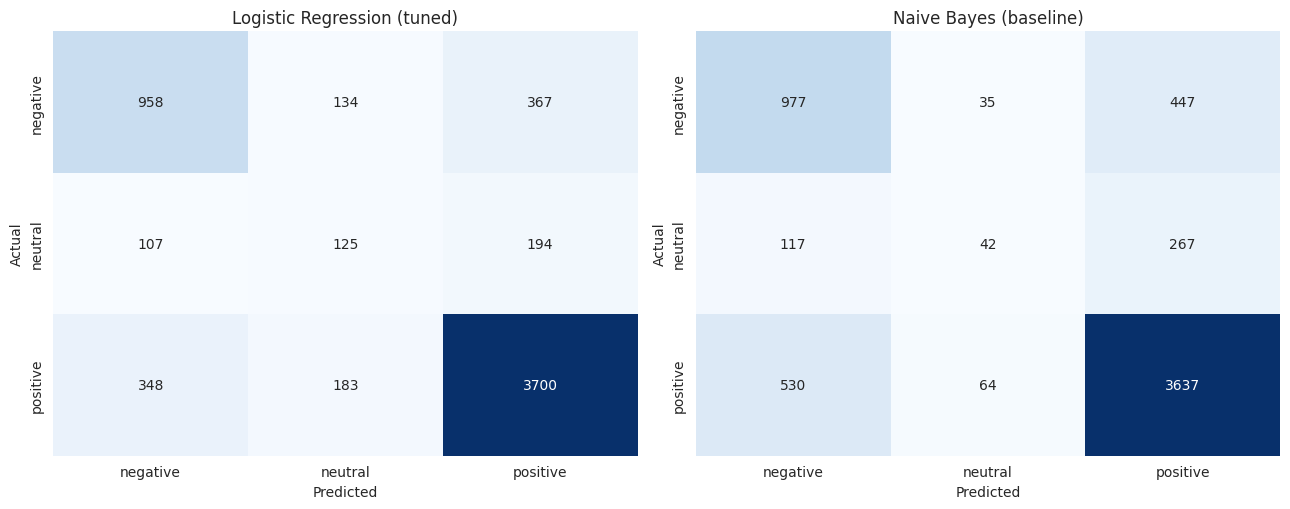

In [14]:
labels_order = ['negative', 'neutral', 'positive']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, pipeline, title in zip(axes, [lr_pipeline, nb_pipeline],
                                 ['Logistic Regression (tuned)', 'Naive Bayes (baseline)']):
    preds = pipeline.predict(X_test)
    cm = pd.crosstab(pd.Series(y_test, name='Actual'), pd.Series(preds, name='Predicted'))
    cm = cm.reindex(index=labels_order, columns=labels_order, fill_value=0)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()


## 10. Model Selection — Macro F1 Comparison

             Logistic Regression  Naive Bayes
Accuracy                  0.7820       0.7613
Macro F1                  0.6089       0.5432
Weighted F1               0.7820       0.7479


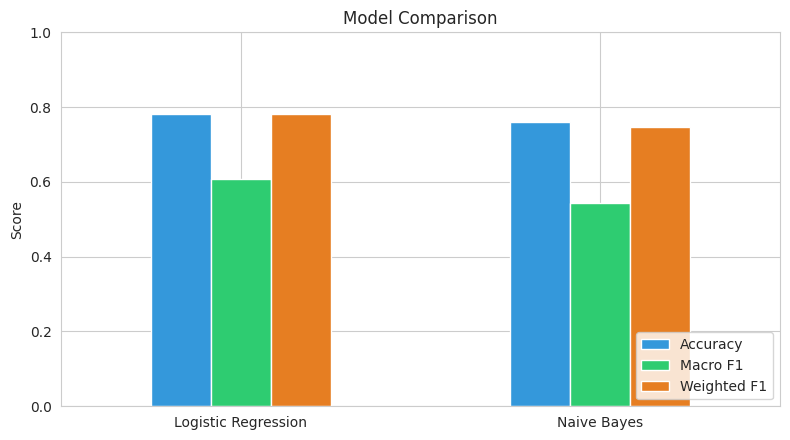


🏆 Selected model: Logistic Regression (higher macro F1 — the fair metric for imbalanced classes)


In [15]:
comparison = pd.DataFrame({
    'Logistic Regression': [lr_metrics['accuracy'], lr_metrics['macro_f1'], lr_metrics['weighted_f1']],
    'Naive Bayes':          [nb_metrics['accuracy'], nb_metrics['macro_f1'], nb_metrics['weighted_f1']],
}, index=['Accuracy', 'Macro F1', 'Weighted F1'])

print(comparison.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
comparison.T.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#e67e22'])
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_pipeline = lr_pipeline if lr_metrics['macro_f1'] >= nb_metrics['macro_f1'] else nb_pipeline
best_name = 'Logistic Regression' if best_pipeline is lr_pipeline else 'Naive Bayes'
print(f'\n🏆 Selected model: {best_name} (higher macro F1 — the fair metric for imbalanced classes)')


## 11. Explainability — Which Words Drive Each Class?

Logistic Regression coefficients directly rank how strongly each word pushes
toward each class — no external library (e.g. SHAP) needed.


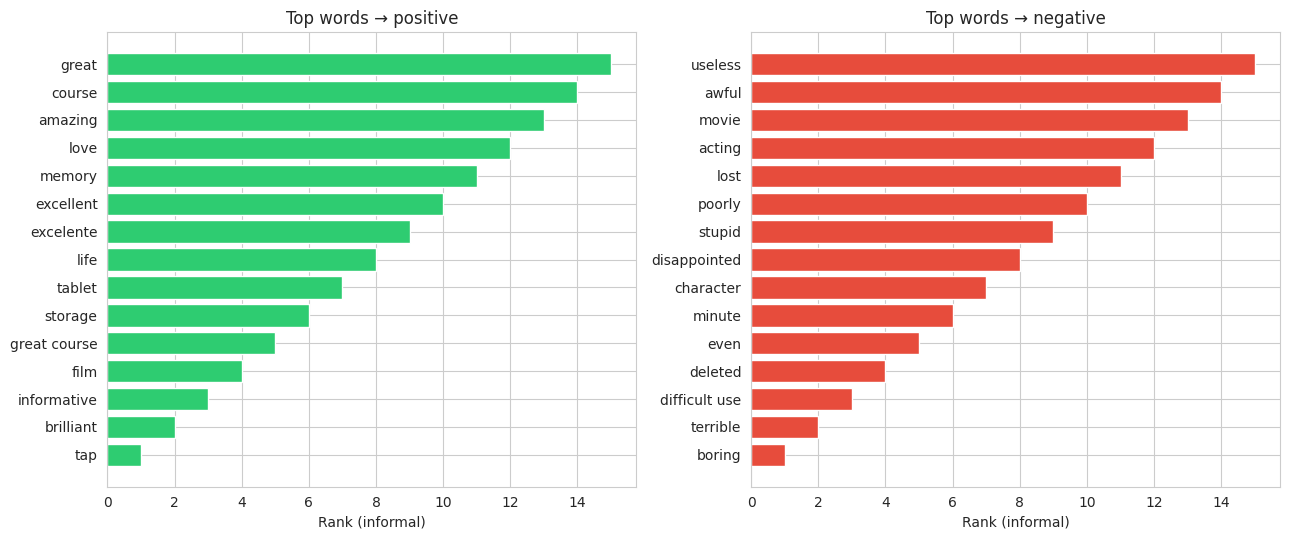

In [16]:
top_features = get_top_features(lr_pipeline, n=15)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, cls, color in zip(axes, ['positive', 'negative'], [LABEL_COLORS['positive'], LABEL_COLORS['negative']]):
    words = top_features.get(cls, [])[::-1]
    ax.barh(words, range(1, len(words) + 1), color=color)
    ax.set_title(f'Top words → {cls}')
    ax.set_xlabel('Rank (informal)')
plt.tight_layout()
plt.show()


## 12. Per-Review Explainability — Including the Neutral Case

`explain_prediction()` scores every word in a review on **two axes**:

```
pos_vs_neg score   = coef[positive] − coef[negative]
neutral_pull score = coef[neutral] − avg(coef[positive], coef[negative])
```

The second axis matters specifically for neutral predictions: without it,
"neutral" could only ever be explained as leftover positive/negative
tug-of-war, never in terms of genuine hedging language ("okay", "nothing
special", "could be better"). See `docs/PROJECT_REPORT.md` §5d for the full
reasoning — this was a real gap identified and fixed during development, not
a feature planned from the start.

The four examples below cover a clear positive, a clear negative, a
genuinely neutral/hedging review, and a mixed review with both positive and
negative signals in the same sentence.


In [17]:
example_reviews = [
    "Absolutely amazing product, best purchase I've ever made, highly recommend!",
    "Terrible experience, completely broke after two days, total waste of money.",
    "This product is okay, nothing special, could be better for the price.",
    "The phone camera is excellent, but battery backup is very poor.",
]

for review in example_reviews:
    clean = preprocess_text(review)
    result = explain_prediction(clean, best_pipeline)

    print(f'Review: {review}')
    print(f'  → Predicted: {result["predicted_label"].upper()}  (confidence: {result["confidence"]:.1%})')
    print(f'  → Positive terms: {result["positive_terms"]}')
    print(f'  → Negative terms: {result["negative_terms"]}')
    print(f'  → Neutral/hedging terms: {result["neutral_terms"]}')
    print(f'  → Explanation: {result["explanation"]}')
    print()


Review: Absolutely amazing product, best purchase I've ever made, highly recommend!
  → Predicted: POSITIVE  (confidence: 98.9%)
  → Positive terms: ['amazing', 'highly recommend', 'highly', 'best', 'product', 'recommend', 'purchase ever', 'best purchase ever', 'best purchase', 'ever made']
  → Negative terms: ['ever', 'made']
  → Neutral/hedging terms: ['best', 'highly recommend', 'product', 'absolutely amazing', 'best purchase', 'best purchase ever', 'purchase ever']
  → Explanation: Review is predominantly positive. Positive signals: amazing, highly recommend, highly, best, product | Negative signals: ever, made

Review: Terrible experience, completely broke after two days, total waste of money.
  → Predicted: NEGATIVE  (confidence: 97.2%)
  → Positive terms: ['experience', 'day']
  → Negative terms: ['terrible', 'waste', 'broke', 'completely', 'two', 'total', 'money', 'terrible experience', 'two day', 'total waste']
  → Neutral/hedging terms: ['day', 'terrible', 'total', 'completel

**Note the third example:** the neutral prediction's explanation leads with
genuine hedging language ("okay", "could better", "nothing special") — not
just a description of weak positive/negative signals. That's the fix
described above, verified here with a real example.


## 13. Try It Yourself

Change `my_review` below and re-run this cell — useful during a live viva
demo if asked to classify a new example on the spot.


In [18]:
my_review = "Great sound quality but the app keeps crashing on my phone."

clean = preprocess_text(my_review)
result = explain_prediction(clean, best_pipeline)

print(f'Review: {my_review}')
print(f'Predicted sentiment: {result["predicted_label"].upper()}')
print(f'Confidence: {result["confidence"]:.1%}')
print(f'Probabilities: {result["probabilities"]}')
print(f'Positive signals: {result["positive_terms"]}')
print(f'Negative signals: {result["negative_terms"]}')
print(f'Explanation: {result["explanation"]}')


Review: Great sound quality but the app keeps crashing on my phone.
Predicted sentiment: POSITIVE
Confidence: 59.3%
Probabilities: {'negative': 0.1326, 'neutral': 0.2743, 'positive': 0.593}
Positive signals: ['great', 'app keep', 'sound', 'phone', 'sound quality', 'great sound quality']
Negative signals: ['crashing', 'quality', 'keep', 'great sound', 'app']
Explanation: Review is predominantly positive. Positive signals: great, app keep, sound, phone, sound quality | Negative signals: crashing, quality, keep, great sound, app


## 14. Conclusion

### Results Summary

| Model | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|
| **Logistic Regression (tuned)** | see Section 10 output above | | |
| Naive Bayes (baseline) | see Section 10 output above | | |

*(Exact numbers depend on the training run — re-run Section 10's cell above for current values; see `models/metadata.json` for the numbers behind the shipped, deployed model.)*

### Key Takeaways

- Trained on **30,801 real reviews** from 13 Kaggle sources — not synthetic text
- Systematic hyperparameter search beat scikit-learn's default `class_weight="balanced"` on macro F1
- Full explainability with no external library: two-axis coefficient scoring covers both the positive/negative spectrum and neutral-specific hedging language
- **Neutral remains the hardest class** (F1 ≈ 0.29, precision ≈ 28%) — this is disclosed explicitly in the dashboard (a warning is shown on every neutral prediction) rather than hidden. This matches published sentiment-analysis literature: neutral sentiment is inherently more ambiguous and rarer in real data than clearly positive or negative text.

### Where to Go From Here

- `train.py` — run the identical pipeline end-to-end from the command line
- `app.py` — the full 8-page Streamlit dashboard built on this model
- `docs/PROJECT_REPORT.md` — the complete experimentation log, including every configuration tried before arriving at the final hyperparameters
- `docs/ARCHITECTURE.md` — data flow diagrams and design-decision rationale
